In [1]:
# ============================================================
# ИМПОРТЫ
# ============================================================
import numpy as np
import gymnasium as gym
from gymnasium import spaces

from stable_baselines3 import PPO
from stable_baselines3.common.callbacks import BaseCallback

import matplotlib.pyplot as plt

Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
Users of this version of Gym should be able to simply replace 'import gym' with 'import gymnasium as gym' in the vast majority of cases.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.


/home/vlad/hw1/.venv/lib/python3.12/site-packages/stable_baselines3/common/on_policy_algorithm.py:150: UserWarning: You are trying to run PPO on the GPU, but it is primarily intended to run on the CPU when not using a CNN policy (you are using ActorCriticPolicy which should be a MlpPolicy). See https://github.com/DLR-RM/stable-baselines3/issues/1245 for more info. You can pass `device='cpu'` or `export CUDA_VISIBLE_DEVICES=` to force using the CPU.Note: The model will train, but the GPU utilization will be poor and the training might take longer than on CPU.
  warnings.warn(


Количество завершённых эпизодов: 5748


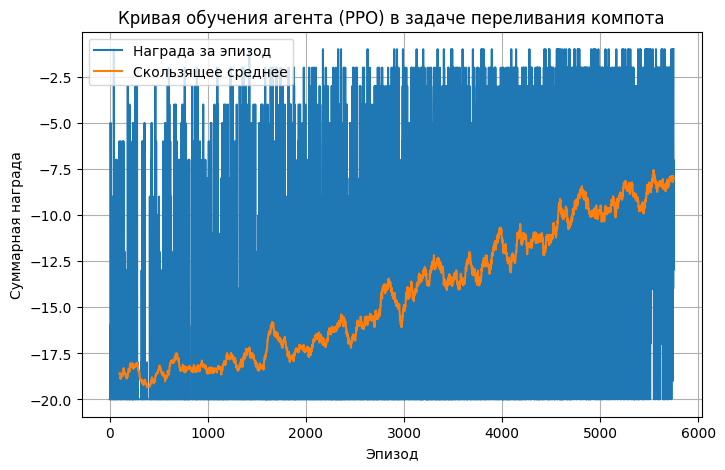

In [ ]:
def format_vec(arr, digits=3):
    """
    Преобразует 1D-массив в строку вида:
    [0.005 0.218 0.182 0.448 0.147]
    без лишних пробелов после '[' и перед ']'.
    """
    arr = np.asarray(arr, dtype=float).ravel()
    parts = []
    for x in arr:
        x_r = round(float(x), digits)
        s = f"{x_r:.{digits}f}".rstrip('0').rstrip('.')
        if s == "-0":
            s = "0"
        if "." not in s:
            s += "."
        parts.append(s)
    return "[" + " ".join(parts) + "]"

class CompoteEnv(gym.Env):
    """
    5 стаканов с компотом. За шаг можно перелить из одного стакана
    сразу в несколько других. Задача — выровнять объёмы.

    Награда: только -1 за шаг (минимизируем число переливаний).
    """

    metadata = {"render_modes": ["human"]}

    def __init__(self):
        super().__init__()

        self.n = 5                          # число стаканов
        self.total = 1.0                    # общий объём компота
        self.target = self.total / self.n   # целевой объём
        self.tol = 0.001                    # строгий допуск по равенству
        self.max_steps = 20                 # максимум шагов в эпизоде

        # Состояние — объёмы в стаканах
        self.observation_space = spaces.Box(
            low=0.0,
            high=self.total,
            shape=(self.n,),
            dtype=np.float32
        )

        # Строим список всех действий: (src, dest_indices_list)
        self.action_map = []
        for src in range(self.n):
            others = [i for i in range(self.n) if i != src]
            # маски всех непустых подмножеств other-ов
            for mask in range(1, 1 << len(others)):
                dests = [others[j] for j in range(len(others)) if mask & (1 << j)]
                self.action_map.append((src, dests))

        self.num_actions = len(self.action_map)
        self.action_space = spaces.Discrete(self.num_actions)

        self.state = None
        self.last_delta = np.zeros(self.n, dtype=np.float32)
        self.step_count = 0

    # ---------- Вспомогательные методы ----------

    def _random_state(self):
        """Случайно распределяем общий объём по стаканам (сумма = total)."""
        x = np.random.rand(self.n).astype(np.float32)
        x /= x.sum()
        return x * self.total

    def _is_done(self, state):
        """Проверяем, выровнены ли стаканы (все близки к target)."""
        return np.all(np.abs(state - self.target) < self.tol)

    # ---------- Методы Gymnasium ----------

    def reset(self, *, seed=None, options=None):
        super().reset(seed=seed)
        self.step_count = 0
        self.state = self._random_state()
        self.last_delta = np.zeros(self.n, dtype=np.float32)
        return self.state.copy(), {}

    def step(self, action):
        self.step_count += 1

        # Декодируем действие в (src, dests)
        src, dests = self.action_map[int(action)]

        volumes = self.state.copy()
        delta = np.zeros_like(volumes, dtype=np.float32)

        if volumes[src] > 0:
            # Сколько "лишнего" у источника относительно target
            excess_src = max(volumes[src] - self.target, 0.0)

            # Сколько не хватает выбранным dest до target
            needs = []
            for d in dests:
                needs.append(max(self.target - volumes[d], 0.0))
            needs = np.array(needs, dtype=np.float32)
            total_need = float(needs.sum())

            if excess_src > 0 and total_need > 0:
                # Переливаем не больше, чем лишнее у src и не больше, чем суммарный дефицит у dests
                poured = min(excess_src, total_need)
                if poured > 0:
                    for d, need_d in zip(dests, needs):
                        if need_d > 0:
                            part = poured * (need_d / total_need)
                            delta[d] += part
                    delta[src] -= poured
            else:
                # Если нет явного лишнего/дефицита — наливаем половину src поровну в выбранные стаканы
                poured = volumes[src] / 2.0
                if poured > 0:
                    share = poured / len(dests)
                    for d in dests:
                        delta[d] += share
                    delta[src] -= poured

        # Обновляем состояние
        new_state = volumes + delta
        new_state = np.clip(new_state, 0.0, self.total)

        # Нормируем сумму обратно к total (на всякий случай)
        s = new_state.sum()
        if s > 0:
            new_state = new_state / s * self.total

        self.state = new_state
        self.last_delta = delta

        # --- Награда: только -1 за каждый шаг ---
        reward = -1.0

        terminated = False
        truncated = False

        if self._is_done(self.state):
            terminated = True
        elif self.step_count >= self.max_steps:
            truncated = True

        info = {
            "is_success": self._is_done(self.state),
            "delta": self.last_delta.copy(),  # на всякий случай
        }

        return self.state.copy(), reward, terminated, truncated, info

    def render(self):
        """Печатаем текущее состояние и изменения за шаг красивым форматом."""
        print("Изменения:", format_vec(self.last_delta, digits=3))
        print("Объёмы   :", format_vec(self.state, digits=3))
        print("-" * 40)

class RewardLogger(BaseCallback):
    """Простой callback: хранит суммарную награду за каждый эпизод."""

    def __init__(self, verbose=0):
        super().__init__(verbose)
        self.episode_rewards = []
        self.current_reward = 0.0

    def _on_step(self) -> bool:
        r = float(self.locals["rewards"][0])
        d = bool(self.locals["dones"][0])

        self.current_reward += r
        if d:
            self.episode_rewards.append(self.current_reward)
            self.current_reward = 0.0
        return True

env = CompoteEnv()

model = PPO(
    policy="MlpPolicy",
    env=env,
    verbose=0,
    seed=42
)

reward_logger = RewardLogger()

model.learn(total_timesteps=80_000, callback=reward_logger)

print("Количество завершённых эпизодов:", len(reward_logger.episode_rewards))

rewards = np.array(reward_logger.episode_rewards, dtype=np.float32)

if len(rewards) == 0:
    print("Эпизоды не были собраны (проверьте обучение).")
else:
    plt.figure(figsize=(8, 5))
    plt.plot(rewards, label="Награда за эпизод")

    if len(rewards) > 10:
        window = 100
        kernel = np.ones(window) / window
        smoothed = np.convolve(rewards, kernel, mode="valid")
        plt.plot(range(window - 1, window - 1 + len(smoothed)),
                 smoothed, label="Скользящее среднее")

    plt.xlabel("Эпизод")
    plt.ylabel("Суммарная награда")
    plt.title("Кривая обучения агента (PPO) в задаче переливания компота")
    plt.grid(True)
    plt.legend()
    plt.show()

In [3]:
while True:
    s = input("Введите 5 неотрицательных объёмов через пробел (сумма = 1.0): ")
    try:
        vols = np.array([float(x) for x in s.strip().split()], dtype=np.float32)
    except ValueError:
        print("Ошибка ввода. Нужно 5 неотрицательных чисел, их сумма должна быть 1.0.")
        continue

    # одна универсальная проверка
    if (
        len(vols) != 5 or
        np.any(vols < 0) or
        abs(float(vols.sum()) - 1.0) > 1e-6  # сумма должна быть 1.0
    ):
        print("Ошибка ввода. Нужно 5 неотрицательных чисел, их сумма должна быть 1.0.")
        continue
    break

# НИКАКОЙ нормализации — используем ровно то, что ввёл пользователь
test_env = CompoteEnv()
obs, _ = test_env.reset()
test_env.state = vols.copy()
test_env.last_delta = np.zeros_like(vols)
obs = test_env.state.copy()

print("\n=== ТЕСТОВЫЙ ЗАПУСК АГЕНТА ===")
print("Начальные объёмы:", format_vec(obs, digits=3))
print("-" * 40)

terminated = False
truncated = False
step = 0
max_test_steps = 15

while not (terminated or truncated) and step < max_test_steps:
    action, _ = model.predict(obs, deterministic=True)
    obs, reward, terminated, truncated, info = test_env.step(action)
    test_env.render()
    step += 1

if info.get("is_success", False):
    print(f"УСПЕХ: объёмы выровнены за {step} переливаний.")
else:
    print("Не удалось полностью выровнять стаканы за отведённые шаги.")

Ошибка ввода. Нужно 5 неотрицательных чисел, их сумма должна быть 1.0.

=== ТЕСТОВЫЙ ЗАПУСК АГЕНТА ===
Начальные объёмы: [0.23 0.38 0.11 0.05 0.23]
----------------------------------------
Изменения: [0. -0.18 0.067 0.112 0.]
Объёмы   : [0.23 0.2 0.177 0.162 0.23]
----------------------------------------
Изменения: [-0.03 0. 0.011 0.019 0.]
Объёмы   : [0.2 0.2 0.189 0.181 0.23]
----------------------------------------
Изменения: [0. 0. 0.011 0.019 -0.03]
Объёмы   : [0.2 0.2 0.2 0.2 0.2]
----------------------------------------
УСПЕХ: объёмы выровнены за 3 переливаний.
